# Import & Setup

In [1]:
import os
if os.path.exists('digit_recognizer'):
    !rm -rf digit_recognizer
!git clone https://github.com/Sirius-Siru/digit_recognizer.git

import sys
if '/content/digit_recognizer' not in sys.path:
    sys.path.append('/content/digit_recognizer')

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

if os.path.isdir('data') and os.path.exists('data/train.csv'):
    print("✨ Dữ liệu đã sẵn sàng, không cần tải lại.")
else:
    print("🚀 Đang tải dữ liệu...")
    !kaggle competitions download -c digit-recognizer
    !unzip -o digit-recognizer.zip -d data
    !rm -f digit-recognizer.zip

Cloning into 'digit_recognizer'...
remote: Enumerating objects: 212, done.
remote: Counting objects: 100% (212/212), done.
remote: Compressing objects: 100% (147/147), done.
remote: Total 212 (delta 113), reused 162 (delta 64), pack-reused 0 (from 0)
Receiving objects: 100% (212/212), 1.02 MiB | 14.96 MiB/s, done.
Resolving deltas: 100% (113/113), done.
✨ Dữ liệu đã sẵn sàng, không cần tải lại.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import src.preprocessing as pp

import gc
from joblib import Parallel, delayed

# Load data

In [3]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

X = train.drop('label', axis=1)
y = train['label']

# Unflatten & Normalize
train_img = X.values.reshape(-1, 28, 28) / 255.0
test_img = test.values.reshape(-1, 28, 28) / 255.0

# Preprocessing

In [ ]:
from tensorflow.keras.utils import to_categorical

X = Parallel(n_jobs = -1)(delayed(pp.cnn_preprocess)(img) for img in train_img)
test = Parallel(n_jobs = -1)(delayed(pp.cnn_preprocess)(img) for img in test_img)

X = np.array(X)
test = np.array(test)

y = to_categorical(y, num_classes=10)

del train_img, test_img
gc.collect()

54

# Setup model

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Activation

def random_thickness(image):
    alpha = tf.random.uniform([], 0.9, 1.1)
    return tf.clip_by_value(image * alpha, 0.0, 1.0)

data_augmentation = models.Sequential([
  layers.RandomRotation(0.08, input_shape=(28, 28, 1)),
  layers.RandomZoom(0.05),
  layers.RandomTranslation(0.05, 0.05),
  layers.RandomGaussianBlur(0.01),
  layers.Lambda(lambda x: random_thickness(x))
])

model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.Conv2D(32, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.Conv2D(64, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(optimizer='adam',
              loss=loss,
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
# Train-Test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Train model

In [7]:
print(y[len(y) * 90 // 100 :].value_counts().sort_index())

label
0    455
1    458
2    392
3    448
4    438
5    354
6    413
7    421
8    397
9    424
Name: count, dtype: int64


In [8]:
print(type(X))

<class 'numpy.ndarray'>


In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_val, y_val), callbacks = [early_stop, reduce_lr])

Epoch 1/50


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(64, 1), output.shape=(64, 10)

263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step
Accuracy = 99.31


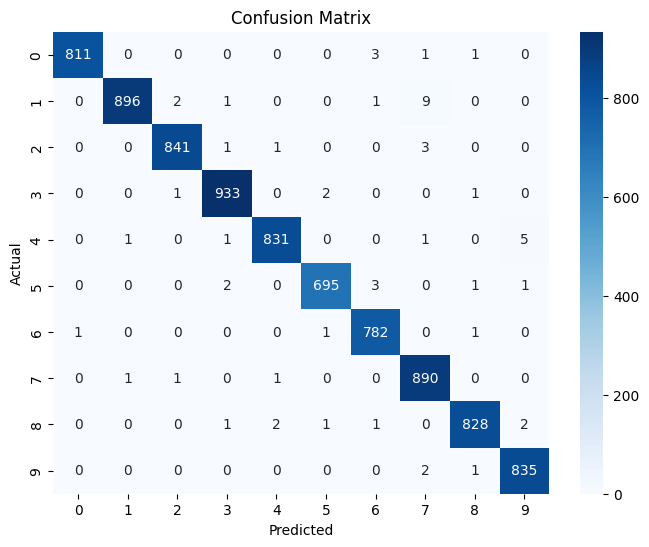

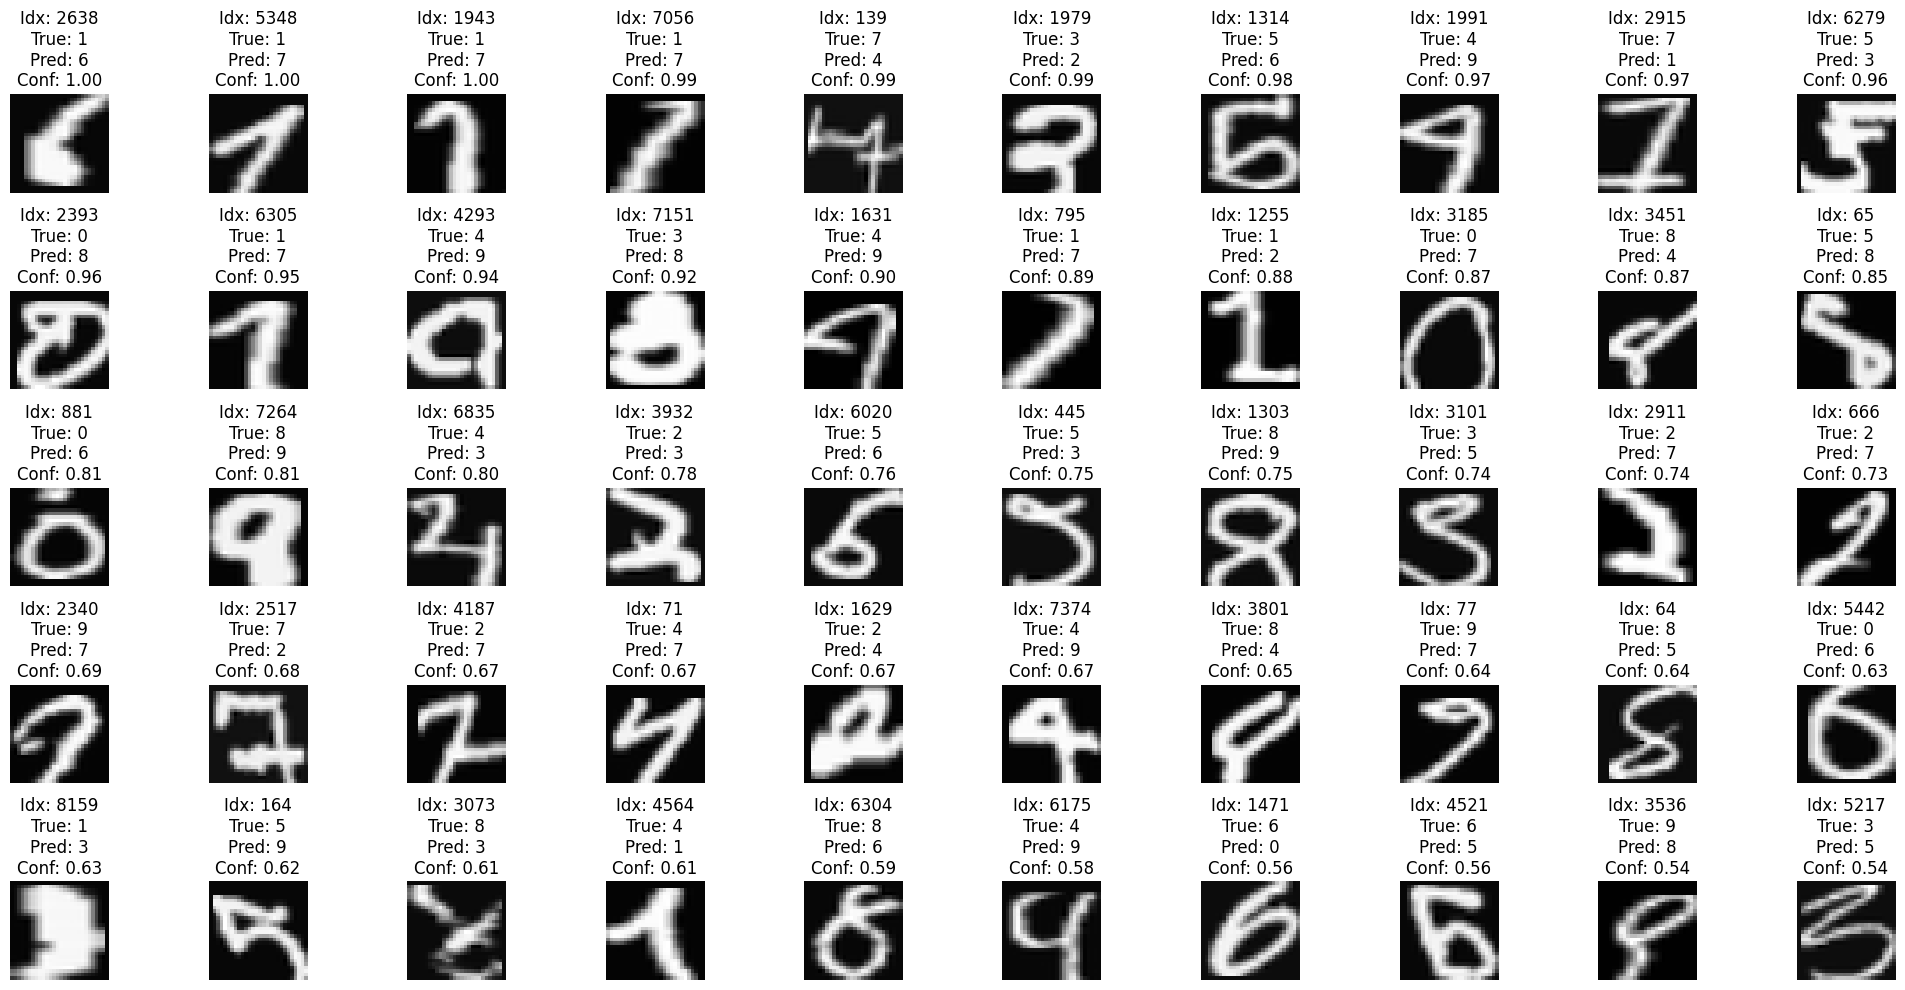

In [ ]:
import src.evaluate as eva
probs = model.predict(X_val)
y_pred = np.argmax(probs, axis=1)
eva.evaluate(y_val, y_pred)
eva.showWrongCase(model, X_val, y_val, probs) 

# Submission

In [ ]:
# model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
#               loss=loss,
#               metrics=['accuracy'])

# model.fit(X, y, epochs=5)
# submission = model.predict(test)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 144s 105ms/step - accuracy: 0.9885 - loss: 0.0382
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 134s 102ms/step - accuracy: 0.9897 - loss: 0.0354
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 135s 103ms/step - accuracy: 0.9890 - loss: 0.0367
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 134s 102ms/step - accuracy: 0.9886 - loss: 0.0376
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 135s 102ms/step - accuracy: 0.9892 - loss: 0.0381
875/875 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step


In [ ]:
# labels = np.argmax(submission, axis = 1)
# submission = pd.DataFrame(data = labels, columns=['Label'])
# submission.insert(0, 'ImageId', range(1, len(submission)+1))
# submission.to_csv('submission.csv', index = False)

In [ ]:
# !kaggle competitions submit -c digit-recognizer -f submission.csv  -m "First submit of the day"

100% 208k/208k [00:00<00:00, 350kB/s]
Successfully submitted to Digit Recognizer